In [1]:
"""
# 02 — Primera CNN sobre MNIST

Módulo: 05 — Deep Learning para Clasificación  
Framework: TensorFlow / Keras  
Dataset: MNIST — dígitos escritos a mano (28×28 px, 10 clases)

## ¿Qué vamos a aprender en este notebook?

1. Cargar y explorar el dataset MNIST
2. Adaptar la CNN del notebook 01 para clasificación multiclase
3. Entender la diferencia entre clasificación binaria y multiclase
4. Analizar los resultados con una matriz de confusión
5. Identificar qué dígitos confunde el modelo y por qué
"""

'\n# 02 — Primera CNN sobre MNIST\n\nMódulo: 05 — Deep Learning para Clasificación  \nFramework: TensorFlow / Keras  \nDataset: MNIST — dígitos escritos a mano (28×28 px, 10 clases)\n\n## ¿Qué vamos a aprender en este notebook?\n\n1. Cargar y explorar el dataset MNIST\n2. Adaptar la CNN del notebook 01 para clasificación multiclase\n3. Entender la diferencia entre clasificación binaria y multiclase\n4. Analizar los resultados con una matriz de confusión\n5. Identificar qué dígitos confunde el modelo y por qué\n'

In [2]:
"""
## 1. De clasificación binaria a multiclase

En el notebook 01 teníamos "2 clases" (círculo o cuadrado).
MNIST tiene "10 clases" (dígitos del 0 al 9). Esto implica tres cambios clave:

| Componente | Notebook 01 (binario) | Notebook 02 (multiclase) |
|---|---|---|
| Última capa | `Dense(1, activation='sigmoid')` | "Dense(10, activation='softmax')" |
| Loss | "binary_crossentropy" | "sparse_categorical_crossentropy" |
| Output | 1 probabilidad (0 a 1) | 10 probabilidades (suman 1) |

### ¿Qué es Softmax?
Convierte un vector de 10 números en 10 probabilidades que suman 1.
El modelo elige la clase con la probabilidad más alta.

Output antes de Softmax:  [2.1,  0.3, -1.2,  4.5,  0.1, ...]
Output después de Softmax: [0.05, 0.01, 0.00, 0.89, 0.01, ...]
↑
clase predicha: 3

### ¿Qué es "sparse_categorical_crossentropy"?
Es la loss para multiclase cuando las etiquetas son enteros (0, 1, 2...9)
en vez de one-hot vectors ([0,0,1,0...]).
"""

'\n## 1. De clasificación binaria a multiclase\n\nEn el notebook 01 teníamos "2 clases" (círculo o cuadrado).\nMNIST tiene "10 clases" (dígitos del 0 al 9). Esto implica tres cambios clave:\n\n| Componente | Notebook 01 (binario) | Notebook 02 (multiclase) |\n|---|---|---|\n| Última capa | `Dense(1, activation=\'sigmoid\')` | "Dense(10, activation=\'softmax\')" |\n| Loss | "binary_crossentropy" | "sparse_categorical_crossentropy" |\n| Output | 1 probabilidad (0 a 1) | 10 probabilidades (suman 1) |\n\n### ¿Qué es Softmax?\nConvierte un vector de 10 números en 10 probabilidades que suman 1.\nEl modelo elige la clase con la probabilidad más alta.\n\nOutput antes de Softmax:  [2.1,  0.3, -1.2,  4.5,  0.1, ...]\nOutput después de Softmax: [0.05, 0.01, 0.00, 0.89, 0.01, ...]\n↑\nclase predicha: 3\n\n### ¿Qué es "sparse_categorical_crossentropy"?\nEs la loss para multiclase cuando las etiquetas son enteros (0, 1, 2...9)\nen vez de one-hot vectors ([0,0,1,0...]).\n'

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


In [4]:
"""
## 2. Carga y exploración del dataset MNIST

MNIST es uno de los datasets más clásicos en deep learning:

| Característica | Detalle |
|---|---|
| Imágenes | 70,000 en total |
| Train | 60,000 imágenes |
| Test | 10,000 imágenes |
| Dimensiones | 28×28 píxeles en escala de grises |
| Clases | 10 (dígitos del 0 al 9) |
| Balance | ~7,000 imágenes por clase |

Keras lo descarga automáticamente la primera vez y lo cachea localmente, por lo que la segunda vez que lo uses no necesita conexión a internet.
"""

'\n## 2. Carga y exploración del dataset MNIST\n\nMNIST es uno de los datasets más clásicos en deep learning:\n\n| Característica | Detalle |\n|---|---|\n| Imágenes | 70,000 en total |\n| Train | 60,000 imágenes |\n| Test | 10,000 imágenes |\n| Dimensiones | 28×28 píxeles en escala de grises |\n| Clases | 10 (dígitos del 0 al 9) |\n| Balance | ~7,000 imágenes por clase |\n\nKeras lo descarga automáticamente la primera vez y lo cachea localmente, por lo que la segunda vez que lo uses no necesita conexión a internet.\n'

In [5]:
# Cargar dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar píxeles de [0, 255] a [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Agregar dimensión de canal: (N, 28, 28) → (N, 28, 28, 1)
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Clases: {np.unique(y_train)}")
print(f"Rango de píxeles: [{X_train.min()}, {X_train.max()}]")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train shape: (60000, 28, 28, 1)
X_test shape:  (10000, 28, 28, 1)
y_train shape: (60000,)
Clases: [0 1 2 3 4 5 6 7 8 9]
Rango de píxeles: [0.0, 1.0]


In [6]:
"""
# 3. ¿Por qué normalizamos los píxeles?

Los píxeles originales tienen valores entre 0 y 255. Normalizar a [0, 1] tiene
tres beneficios importantes:

| Beneficio | Explicación |
|---|---|
| Estabilidad numérica | Evita que los gradientes exploten o desaparezcan |
| Convergencia más rápida | El optimizador trabaja mejor con valores pequeños |
| Consistencia | Todas las features están en la misma escala |

Esta es una de las primeras cosas que siempre hay que hacer al trabajar con imágenes. En notebooks posteriores vamos a ver técnicas más avanzadas de normalización como "Batch Normalization".

"""

'\n# 3. ¿Por qué normalizamos los píxeles?\n\nLos píxeles originales tienen valores entre 0 y 255. Normalizar a [0, 1] tiene\ntres beneficios importantes:\n\n| Beneficio | Explicación |\n|---|---|\n| Estabilidad numérica | Evita que los gradientes exploten o desaparezcan |\n| Convergencia más rápida | El optimizador trabaja mejor con valores pequeños |\n| Consistencia | Todas las features están en la misma escala |\n\nEsta es una de las primeras cosas que siempre hay que hacer al trabajar con imágenes. En notebooks posteriores vamos a ver técnicas más avanzadas de normalización como "Batch Normalization".\n\n'

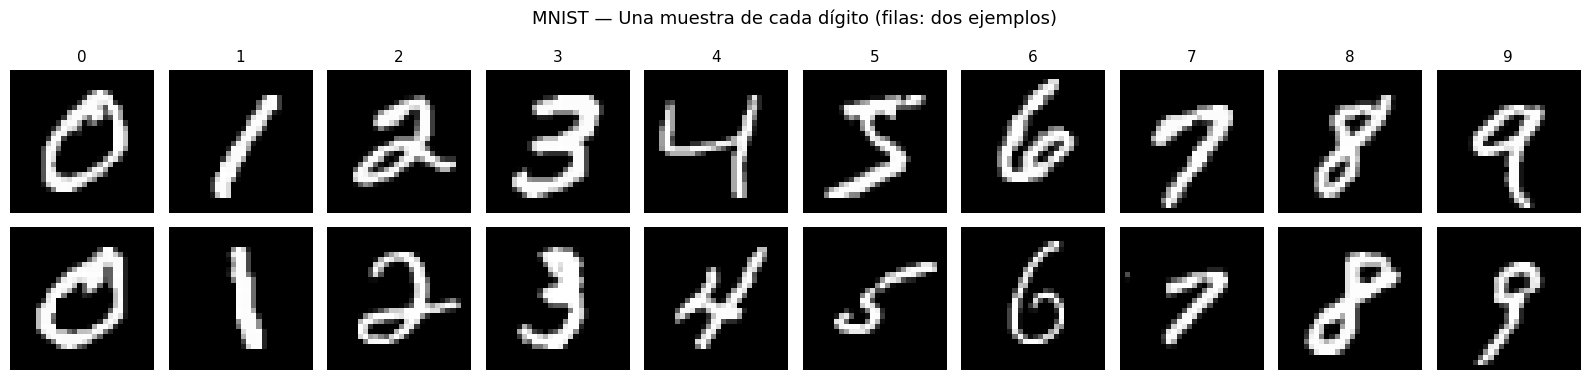

In [7]:
# Visualizar muestras de cada clase
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle('MNIST — Una muestra de cada dígito (filas: dos ejemplos)', fontsize=13)

for digit in range(10):
    # Obtener índices de ese dígito
    idx = np.where(y_train == digit)[0]
    
    # Fila 1: primer ejemplo
    axes[0, digit].imshow(X_train[idx[0], :, :, 0], cmap='gray')
    axes[0, digit].axis('off')
    axes[0, digit].set_title(f'{digit}', fontsize=11)
    
    # Fila 2: segundo ejemplo
    axes[1, digit].imshow(X_train[idx[1], :, :, 0], cmap='gray')
    axes[1, digit].axis('off')

plt.tight_layout()
plt.savefig('../figures/02_mnist_muestras.png', dpi=120, bbox_inches='tight')
plt.show()